In [1]:
import os
import pynwb
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import pywt
import matplotlib
import graph
import time
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec

from scipy import signal
from scipy.fftpack import next_fast_len
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter1d
from scipy.signal import filtfilt, hilbert, remez, sosfiltfilt, butter, coherence
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed

import load_data
import LFP
import graph

from fooof import FOOOF
from fooof import FOOOFGroup
from fooof import Bands
from fooof.plts.periodic import plot_peak_fits, plot_peak_params
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg, get_band_peak_fm
from fooof.plts.spectra import plot_spectra
from fooof.sim.gen import gen_aperiodic
from fooof.plts.aperiodic import plot_aperiodic_params, plot_aperiodic_fits

C:\Users\Admin\AppData\Local\Temp\ipykernel_20256\3123265191.py:31: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
class AlphaDataset:
    
    def __init__(self, h5_path):
        self.f = h5py.File(h5_path, 'r')
        self.band_sig = self.f['band_sig']
        self.power = self.f['power']
        self.phase = self.f['phase']
        self.timestamps = self.f['timestamps']

    def get_trace(self, time):
        return self.band_sig[time, :].T, self.power[time, :].T, self.phase[time, :].T

    def get_band_sig(self, time):
        return self.band_sig[time, :]

    def get_power(self, time):
        return self.power[time, :]

    def get_phase(self, time):
        return self.phase[time, :]

    def close(self):
        self.f.close()

In [3]:
def epoch_aligned_lfp(date,df,window):

    timestamps, lfpData = load_data.load_LFP(date)
    
    num_ch = lfpData.shape[1]
    aligned_lfp = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_lfp[ii,:,:] = LFP.preprocess_LFP(lfpData[idx,:].T.astype(np.float32)) 
    
    return aligned_lfp

In [4]:
def plot_sem(time, trace, ax, ii, label, colors = 'Blues_r'):

    colors = sns.color_palette(colors,4)
    mean_trace = trace.mean(axis=0)
    sem_trace = trace.std(axis=0)/np.sqrt(trace.shape[0])
    ax.plot(time, mean_trace, color=colors[ii], label=label)
    ax.fill_between(time,
                    mean_trace - sem_trace,
                    mean_trace + sem_trace,
                    color=colors[ii],
                    alpha=0.3)

In [5]:
def get_highest_power_channel(df, ses):
    
    session_df = df[
        (df['frequency'] > 10) &
        (df['frequency'] < 30) &
        (df['session'] == ses)
    ]
    
    channels = (
        session_df
        .groupby('channel', as_index=False)['power']
        .max()
        .merge(
            session_df[['probe','channel','subfield']].drop_duplicates(),
            on='channel',
            how='left'
        )
    )

    return channels.loc[channels.groupby('probe')['power'].idxmax()]

In [24]:
def stratified_permutation(labels, random_state=None):
    
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)

    shuffled_idx = np.arange(len(labels))

    for lab in np.unique(labels):
        mask = labels == lab
        shuffled_idx[mask] = rng.permutation(shuffled_idx[mask])

    return shuffled_idx

In [56]:
def get_session_coherence(action_aligned, all_spec, date, choice_df, fs=1000):

    # parameters for calculating coherence
    nperseg = fs*0.5 #action_aligned.shape[2]*0.8
    noverlap = nperseg*0.75
    
    # get channel number with the highest alpha/beta band power from each probe in a given session to calculate coherence
    channels = get_highest_power_channel(all_spec, date)
    ofc_channels = channels.loc[channels.subfield == 'OFC', 'channel'].values
    hpc_channels = channels.loc[channels.subfield != 'OFC', 'channel'].values
    pairs = list(product(ofc_channels, hpc_channels))
    
    # preallocate array shape
    pairs = list(product(ofc_channels, hpc_channels))   
    n_trials = action_aligned.shape[0]
    n_freqs = int(nperseg // 2 + 1)
    n_pairs = len(pairs)
    
    ofc_hpc_coh_all = np.zeros((n_pairs, n_trials, n_freqs))
    ofc_hpc_coh_null_all = np.zeros_like(ofc_hpc_coh_all)
    
    # shuffled indices for null, shuffling the trial order of HPC channel across alla trials to break the coherence within a trial
    # shuffled_trial_idx = np.random.permutation(n_trials)

    # to account for the broadband feature of each value, shuffle is done separately within each value, so that the broadband feature is remained
    shuffled_trial_idx = stratified_permutation(choice_df.value.values)
    
    # Loop through all pairs
    for i, (ofc_ch, hpc_ch) in enumerate(tqdm(pairs)):
        
        for trial in range(n_trials):
            x = action_aligned[trial, ofc_ch, :]
            y = action_aligned[trial, hpc_ch, :]
        
            # actual coherence
            f_coh, ofc_hpc_coh_all[i, trial, :] = coherence(
                x, y, fs=fs, nperseg=nperseg, noverlap=noverlap
            )
        
            # trial-shuffled coherence (null)
            y_null = action_aligned[shuffled_trial_idx[trial], hpc_ch, :]
            _, ofc_hpc_coh_null_all[i, trial, :] = coherence(
                x, y_null, fs=fs, nperseg=nperseg, noverlap=noverlap
            )

    return f_coh, ofc_hpc_coh_all, ofc_hpc_coh_null_all, pairs, ofc_channels, hpc_channels, channels

100%|██████████| 6/6 [00:00<00:00, 115.13it/s]


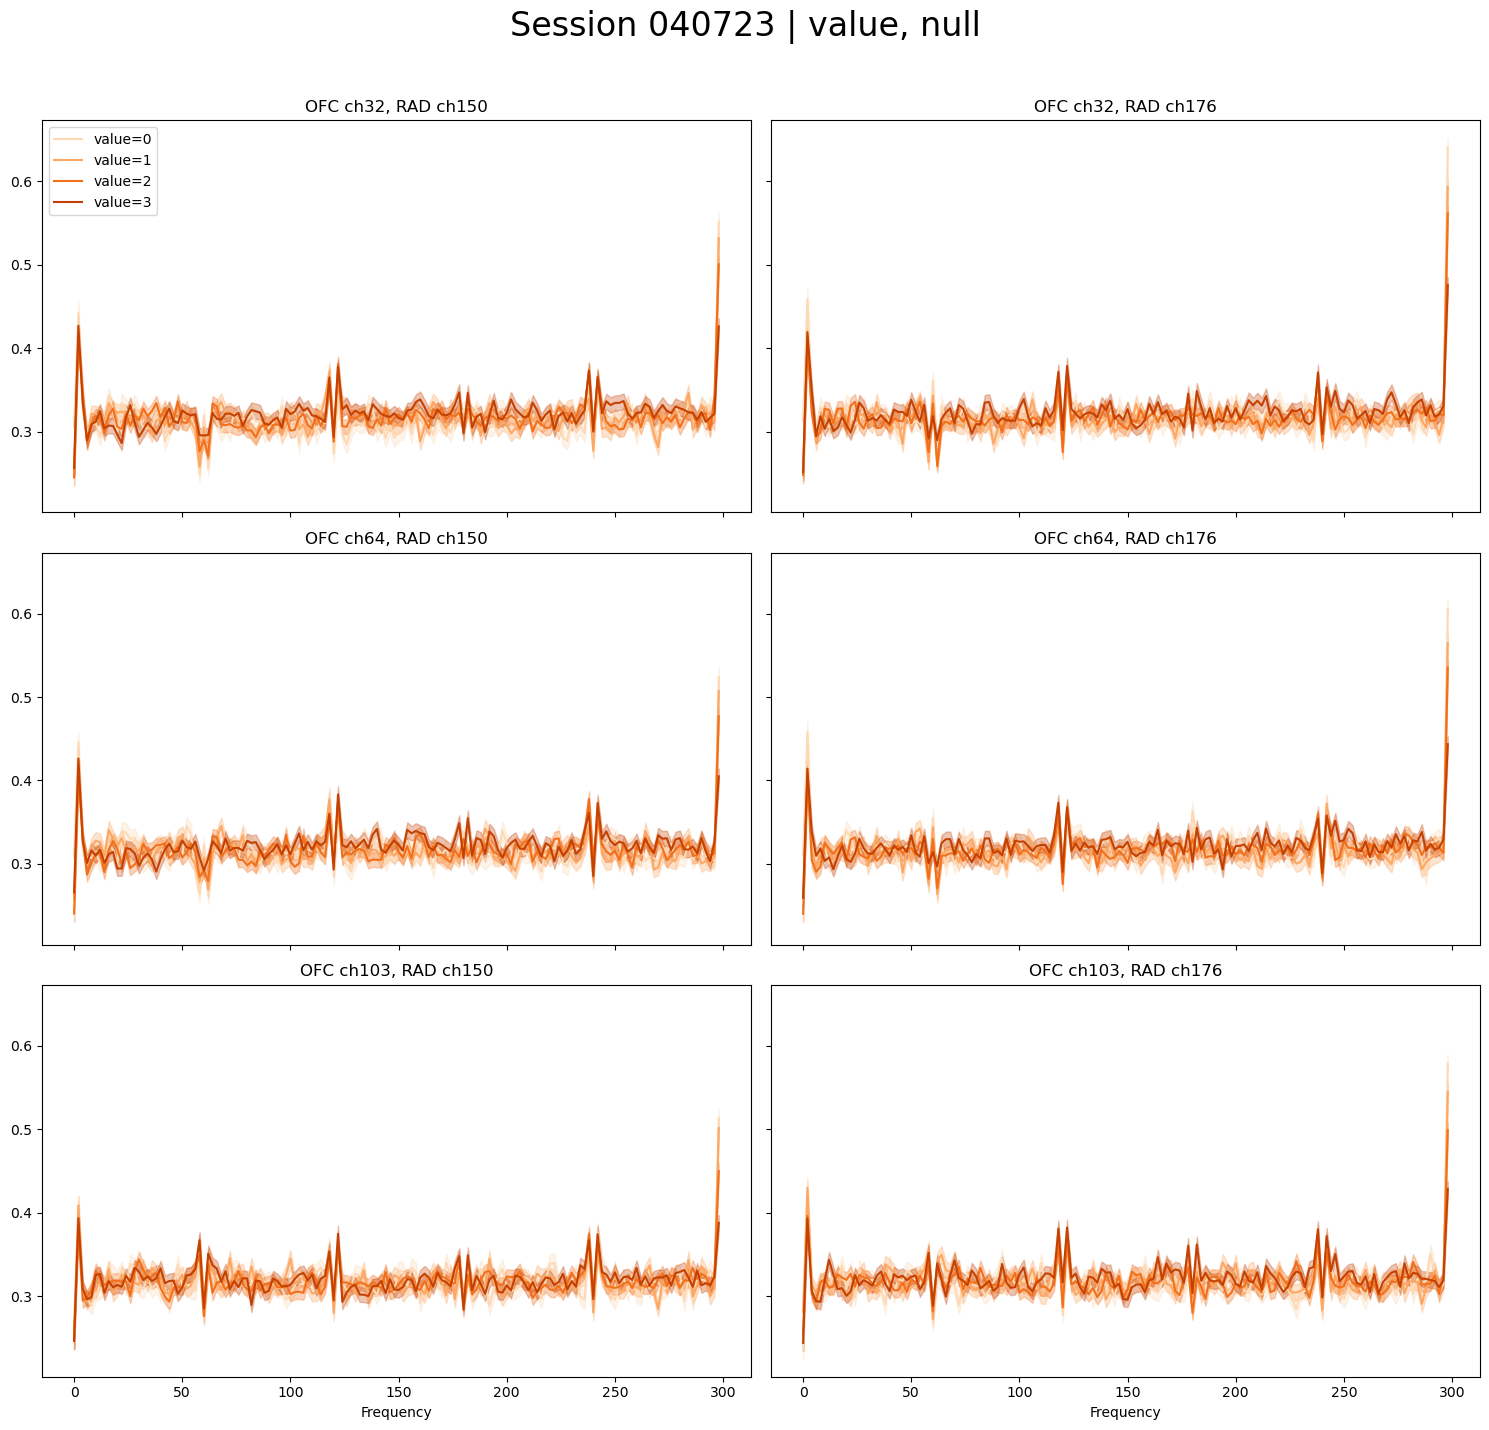

In [62]:
all_spec = pd.read_pickle("D:/Alpha/fooof_flatten_psd.pkl")

for date in ['032823','033123', '032023', '040423', '040723']:
    
    nwbfile = load_data.load_nwbfile('Bart',date) 
    
    query = 'trialerror==0'
    choice_df = nwbfile.intervals['action_on'].to_dataframe().query(query)
    choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)
    action_aligned = epoch_aligned_lfp(date,choice_df,[-250,750])
    
    f_coh, ofc_hpc_coh, ofc_hpc_coh_null, pairs, ofc_channels, hpc_channels, channels = get_session_coherence(action_aligned, all_spec, date, choice_df)
    
    # plot coherence conditioned on value
    
    for mode in ['data','null']:
    
        plt.close('all')
        fig, axes = plt.subplots(len(ofc_channels),len(hpc_channels),figsize=(15,15),sharex=True, sharey=True)
        
        for ii, (ofc_ch, hpc_ch) in enumerate(tqdm(pairs)):
            
            r,c = np.divmod(ii,len(hpc_channels))
            
            for vv in range(4):
                idx = choice_df.value.values==vv    
                if mode=='data':
                    plot_sem(f_coh[f_coh<300], ofc_hpc_coh[ii,idx,:][:,f_coh<300], axes[r,c], vv, f'value={vv}', colors='Blues') 
                if mode=='null':
                    plot_sem(f_coh[f_coh<300], ofc_hpc_coh_null[ii,idx,:][:,f_coh<300], axes[r,c], vv, f'value={vv}', colors='Oranges') 
        
            subfield = channels.query('channel==@hpc_ch').subfield.values[0]
            axes[r,c].set_title(f'OFC ch{pairs[ii][0]}, {subfield} ch{pairs[ii][1]}')
            
            if r==2:
                axes[r,c].set_xlabel('Frequency')
            
        axes[0,0].legend()
        
        plt.tight_layout(rect=[0,0,1,0.9])
        plt.suptitle(f'Session {date} | value, {mode}',y=0.95,fontsize=24)
        plt.savefig(f'D:/Alpha/Coherence, Session {date}, conditioned on value, 0-300 {mode}')

In [ ]:
# look at this for planning

100%|██████████| 9/9 [00:00<00:00, 204.74it/s]


Text(0.5, 0.95, 'Session 031723')

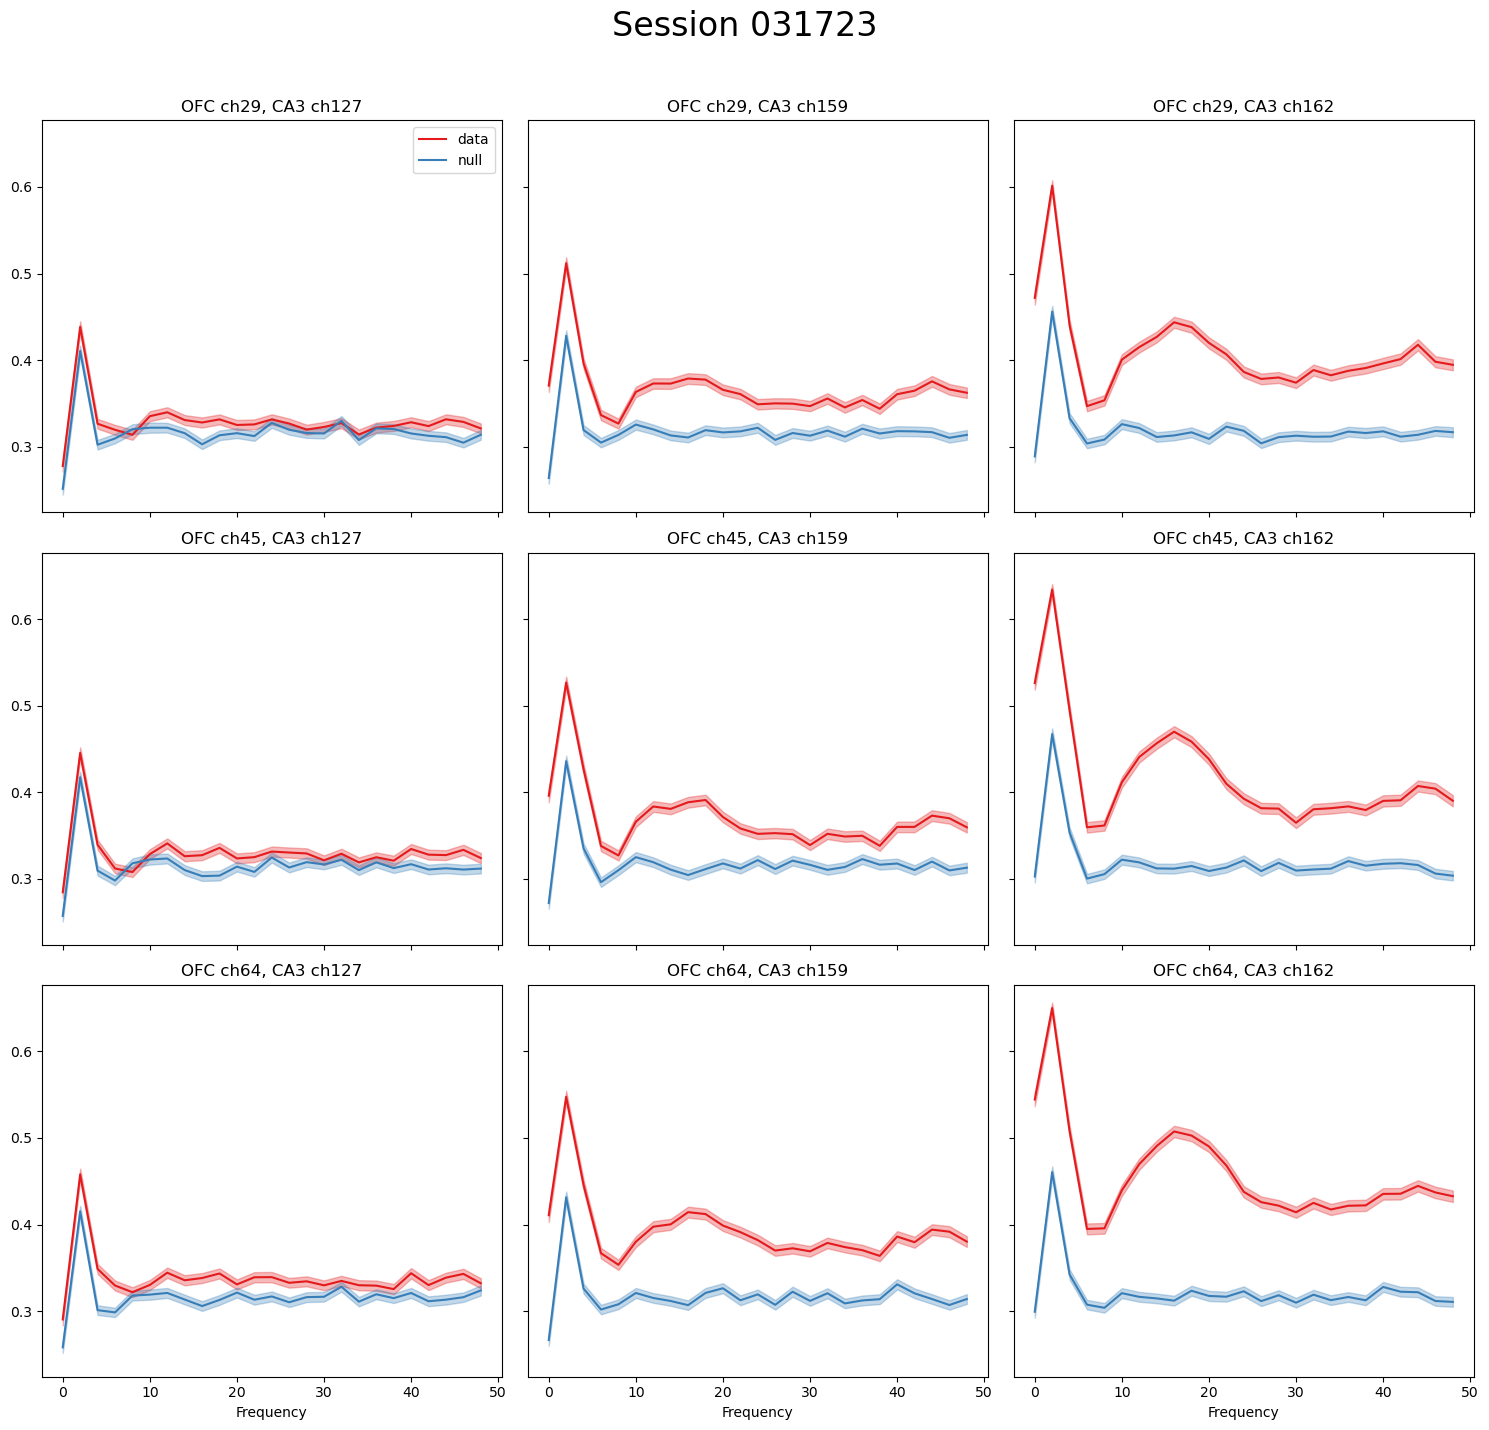

In [59]:
# plot coherence grouped from all trials

plt.close('all')
fig, axes = plt.subplots(len(ofc_channels),len(hpc_channels),figsize=(15,15),sharex=True, sharey=True)

for ii, (ofc_ch, hpc_ch) in enumerate(tqdm(pairs)):
    
    r,c = np.divmod(ii,len(hpc_channels))
    plot_sem(f_coh[f_coh<50], ofc_hpc_coh[ii,:,:][:,f_coh<50], axes[r,c], 0, 'data', colors='Set1') 
    plot_sem(f_coh[f_coh<50], ofc_hpc_coh_null[ii,:,:][:,f_coh<50], axes[r,c], 1, 'null', colors='Set1') 

    subfield = channels.query('channel==@hpc_ch').subfield.values[0]
    axes[r,c].set_title(f'OFC ch{pairs[ii][0]}, {subfield} ch{pairs[ii][1]}')
    
    if r==2:
        axes[r,c].set_xlabel('Frequency')
    
axes[0,0].legend()

plt.tight_layout(rect=[0,0,1,0.9])
plt.suptitle(f'Session {date}',y=0.95,fontsize=24)
# plt.savefig(f'D:/Alpha/Coherence, Session {date}')

In [ ]:
# visually inspect psd of the highest channel
temp = all_spec[(all_spec.channel==69)&(all_spec.session=='031723')] 
plt.close('all')
sns.lineplot(data=temp, x='frequency',y='power',hue='value')


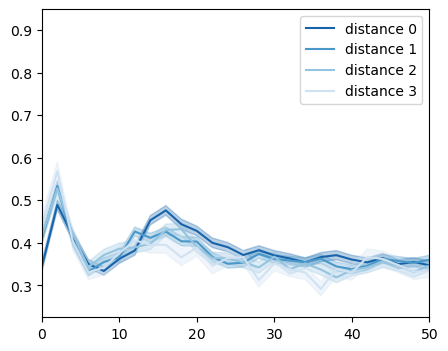

In [118]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_reward[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

In [72]:
# get coherogram
f_coh, ofc_hpc_coh = coherogram(node_aligned[:,95,:],node_aligned[:,187,:])

100%|██████████| 1499/1499 [00:44<00:00, 33.32it/s]


In [116]:
# get imaginery coherence using csd, since signal.coherence only returns squared magnitude
from scipy.signal import csd, welch

fs = 1000
n_trials = action_aligned.shape[0]

nperseg = int(fs * 0.5)
noverlap = int(nperseg * 0.75)

Cxy_imag = np.zeros((n_trials, 251))
Cxy_real = np.zeros((n_trials, 251))

for trial in tqdm(range(n_trials)):

    x = action_aligned[trial, 95, :]
    y = action_aligned[trial, 187, :]

    # cross-spectrum
    f, Pxy = csd(
        x, y,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    # auto-spectra
    _, Pxx = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    _, Pyy = welch(
        y,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    # coherency
    coherency = Pxy / np.sqrt(Pxx * Pyy)

    # imaginary coherence
    Cxy_imag[trial, :] = np.imag(coherency)
    Cxy_real[trial,:] = np.real(coherency)


100%|██████████| 1499/1499 [00:01<00:00, 1342.01it/s]


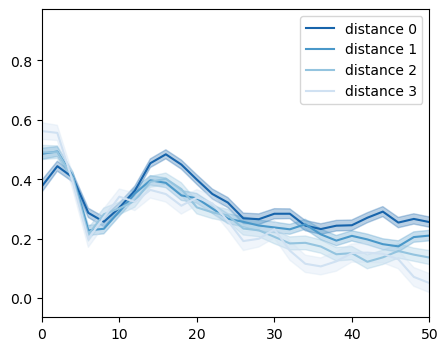

In [119]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_real[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

(array([ 17.,  58., 161., 307., 336., 284., 186., 108.,  34.,   8.]),
 array([-0.5743608 , -0.45605399, -0.33774719, -0.21944038, -0.10113358,
         0.01717323,  0.13548004,  0.25378684,  0.37209365,  0.49040045,
         0.60870726]),
 <BarContainer object of 10 artists>)

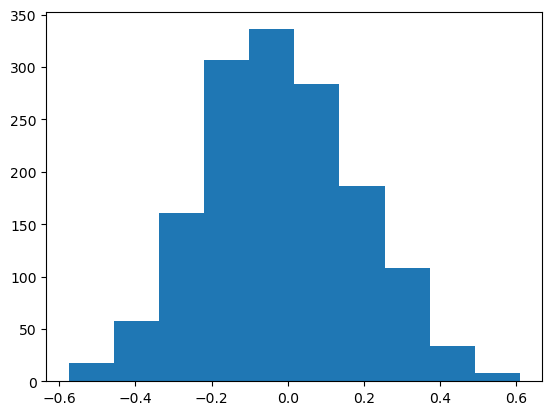

In [123]:
plt.hist(Cxy_imag[:,(f_coh>10)&(f_coh<25)].mean(axis=1))

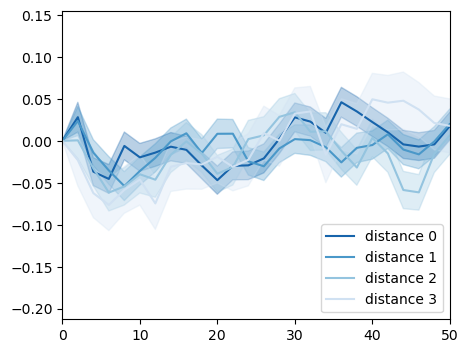

In [120]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_imag[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

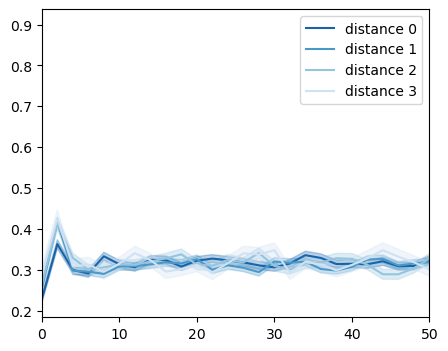

In [109]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_reward[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

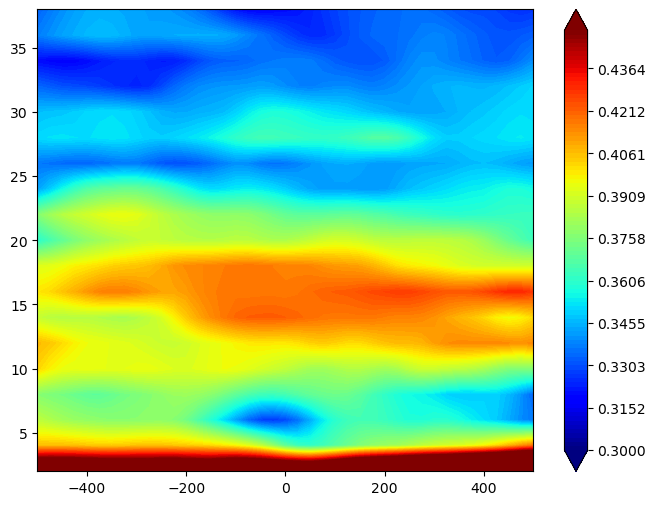

In [76]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8,6))
window = 500
slide=25
idx = (node_df.trialerror==0) & (node_df.step==0) #& (node_df.node!=node_df.target)
timestamps = np.arange(-1000+window, 1000-window+slide, slide)

c = ax.contourf(
    timestamps,
    f_coh[(f_coh<40)&(f_coh>0)],
    ofc_hpc_coh[idx,:,:].mean(axis=0).T[(f_coh<40)&(f_coh>0),:],
    cmap='jet',
    levels = np.linspace(0.3, 0.45, 100),
    extend='both'
)
plt.colorbar(c,ax=ax)

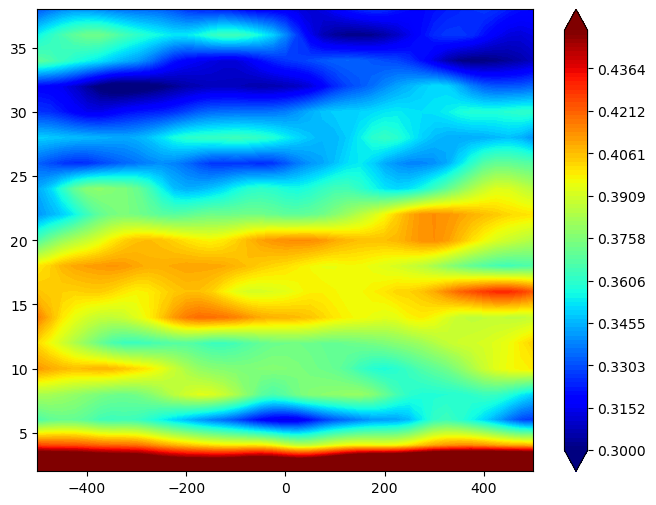

In [83]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8,6))
window = 500
slide=25
idx = (node_df.trialerror==0) & (node_df.graph_distance==3) #& (node_df.node!=node_df.target)
timestamps = np.arange(-1000+window, 1000-window+slide, slide)

c = ax.contourf(
    timestamps,
    f_coh[(f_coh<40)&(f_coh>0)],
    ofc_hpc_coh[idx,:,:].mean(axis=0).T[(f_coh<40)&(f_coh>0),:],
    cmap='jet',
    levels = np.linspace(0.3, 0.45, 100),
    extend='both'
)
plt.colorbar(c,ax=ax)

In [53]:
def coherogram(sig1, sig2, window = 500, slide=25, fs=1000):
    
    timestamps = np.arange(window, sig1.shape[1]-window+slide, slide)
    
    Cxy = np.zeros((sig1.shape[0],len(timestamps),251))

    for trial in tqdm(range(sig1.shape[0])):

        for ii, tt in enumerate(timestamps):
        
            f_coh, Cxy[trial,ii,:] = coherence(sig1[trial,tt-window:tt+window],sig2[trial,tt-window:tt+window],fs=fs,nperseg=fs/2,noverlap=fs/2*0.75)

    return f_coh, Cxy